-----------------------------------
Expanded :  A
g = 0
h = 7
f  7


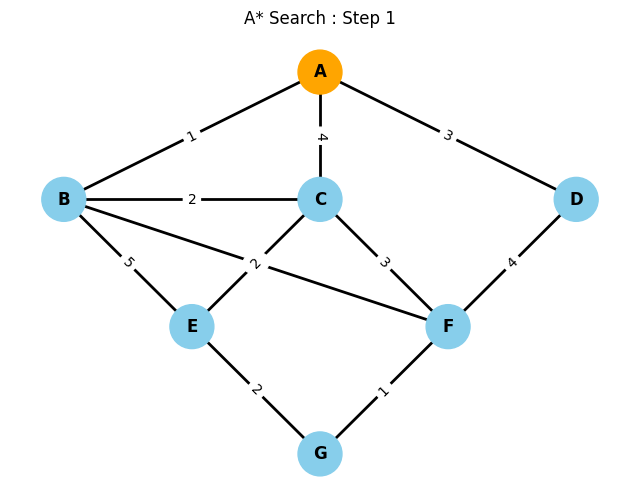

B: g=1, h=6, f=7
C: g=4, h=4, f=8
D: g=3, h=5, f=8
-----------------------------------
Expanded :  B
g = 1
h = 6
f  7


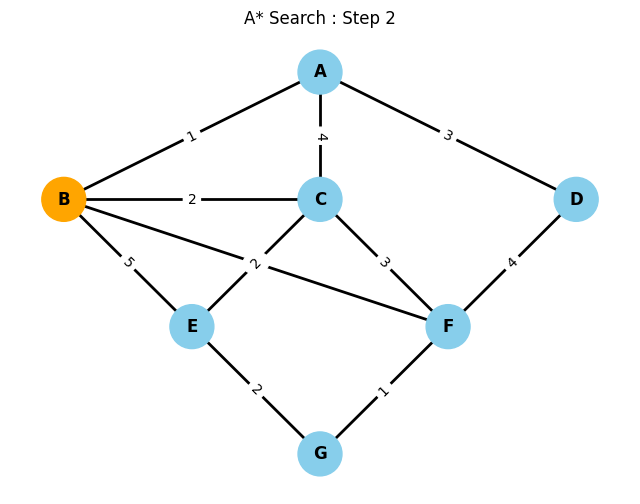

C: g=3, h=4, f=7
F: g=3, h=1, f=4
-----------------------------------
Expanded :  F
g = 3
h = 1
f  4


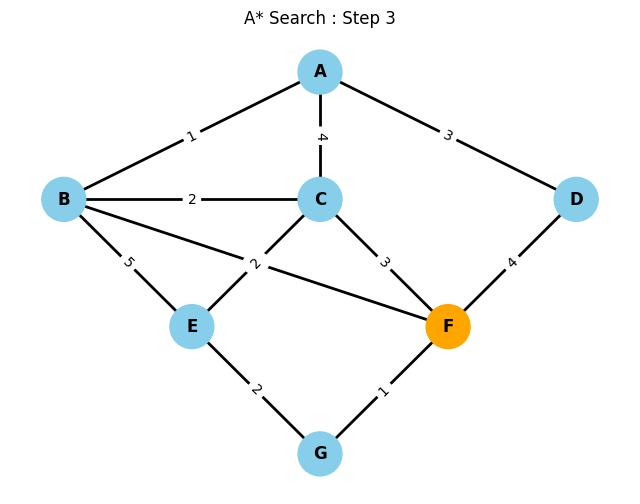

G: g=4, h=0, f=4
-----------------------------------
Expanded :  G
g = 4
h = 0
f  4


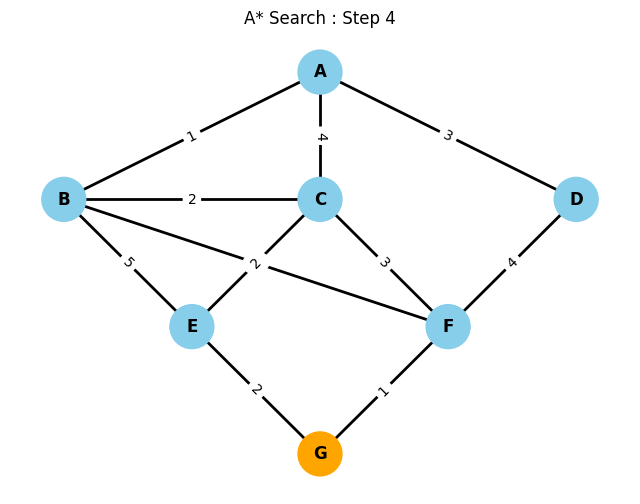


Optimal Path: ['A', 'B', 'F', 'G']
Total Cost: 4


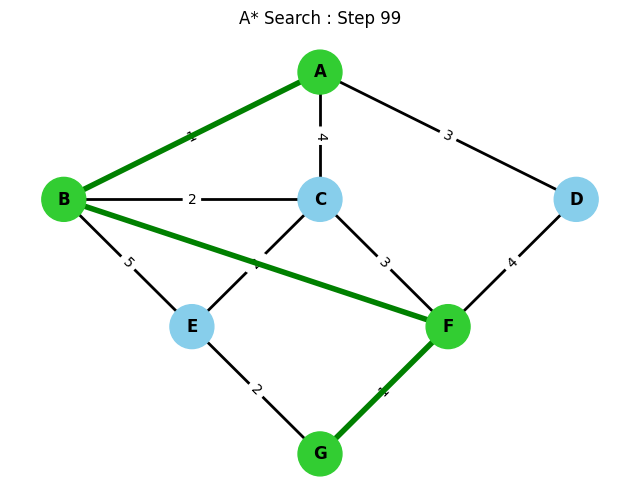

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import heapq

graph = {
    'A': [('B', 1), ('C', 4), ('D', 3)],
    'B': [('A', 1), ('C', 2), ('F', 2)],
    'C': [('A', 4), ('E', 2), ('F', 3)],
    'D': [('A', 3), ('F', 4)],
    'E': [('B', 5), ('C', 2), ('G', 2)],
    'F': [('B', 2), ('C', 3), ('D', 4), ('G', 1)],
    'G': [('E', 2), ('F', 1)]
}
heurisric = {
    'A': 7,
    'B': 6,
    'C': 4,
    'D': 5,
    'E': 3,
    'F': 1,
    'G': 0
}
POS = {
    'A': (2, 4),
    'B': (0, 2),
    'C': (2, 2),
    'D': (4, 2),
    'E': (1, 0),
    'F': (3, 0),
    'G': (2, -2)
}

G = nx.Graph()
for node in graph:
    for neigh, cost in graph[node]:
        G.add_edge(node, neigh, weight=cost)

def draw_graph(current=None, path=None, step=0):
    plt.figure(figsize=(8, 6))
    node_colors = []
    for n in G.nodes():
        if path and n in path:
            node_colors.append("limegreen")
        elif n == current:
            node_colors.append("orange")
        else:
            node_colors.append("skyblue")

    nx.draw_networkx_nodes(
        G, POS,
        node_color=node_colors,
        node_size=1000
    )
    nx.draw_networkx_labels(
        G, POS,
        font_size=12,
        font_weight='bold'
    )
    nx.draw_networkx_edges(G, POS, width=2)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(
        G, POS,
        edge_labels=edge_labels
    )

    if path is not None:
        edges = []
        for i in range(len(path) - 1):
            edges.append((path[i], path[i+1]))
        nx.draw_networkx_edges(
            G, POS,
            edgelist=edges,
            edge_color='green',
            width=4
        )
    plt.title(f"A* Search : Step {step}")
    plt.axis('off')
    plt.savefig(f"step_{step}.png")
    plt.show()

def astar(start_node, goal):
    pq = []
    heapq.heappush(pq, (heurisric[start_node], 0, start_node, [start_node]))
    g_costs = {start_node: 0}

    step = 1
    while pq:
        f, g, node, path = heapq.heappop(pq)
        if g > g_costs.get(node, float('inf')):
            continue
        print("-----------------------------------")
        print("Expanded : ", node)
        print("g =", g)
        print("h =", heurisric[node])
        print("f ", f)
        draw_graph(current=node, step=step)
        step += 1
        if node == goal:
            return path, g
        for neigh, cost in graph[node]:
            new_g = g + cost
            new_f = new_g + heurisric[neigh]
            if new_g < g_costs.get(neigh, float('inf')):
                g_costs[neigh] = new_g
                heapq.heappush(pq, (new_f, new_g, neigh, path + [neigh]))
                print(
                    f"{neigh}: g={new_g}, "
                    f"h={heurisric[neigh]}, "
                    f"f={new_f}"
                )
    return None, None
path, cost = astar('A', 'G')
print("\nOptimal Path:", path)
print("Total Cost:", cost)
draw_graph(path=path, step=99)
